# 05 — Clustering des arrêts IDFM
## Modèle 3 : Segmentation des 772 arrêts en profils types

---

**Objectif** : Regrouper automatiquement les 772 arrêts en familles selon leur comportement de trafic.

### Apprentissage NON supervisé
Comme la détection d'anomalies, le clustering est non supervisé.
On n'a pas d'étiquette 'type d'arrêt' — l'algorithme trouve les groupes tout seul.

### Profils qu'on s'attend à trouver
| Profil | Comportement |
|---|---|
| Hub transport | Très fréquenté, actif 7j/7 (Châtelet, Gare du Nord) |
| Résidentiel | Fort en semaine, calme le week-end (domicile-travail) |
| Touristique | Fort le week-end (Versailles, sites touristiques) |
| Petit arrêt | Faible trafic global (desserte locale) |

### Ce qu'on va faire dans ce notebook
1. Construire les features de profil pour chaque arrêt
2. Trouver le **K optimal** avec 3 méthodes : Elbow, Silhouette, Davies-Bouldin
3. Comparer **3 algorithmes** : K-Means, Clustering Hiérarchique, DBSCAN
4. Réduire les dimensions avec **PCA** pour visualiser
5. Sélectionner le meilleur et interpréter les clusters

### Métriques du clustering (propres au non-supervisé)
- **Silhouette Score** (−1 à 1) : plus c'est haut, mieux les clusters sont séparés
- **Davies-Bouldin** (0 à ∞) : plus c'est BAS, meilleurs les clusters
- **Calinski-Harabasz** : plus c'est haut, meilleurs les clusters

---
## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('Imports OK')

Imports OK


---
## 2. Construction des features de profil par arrêt

### Pourquoi ces features ?
Pour regrouper les arrêts, on doit décrire le **comportement** de chaque arrêt
avec quelques chiffres. On passe de 69 271 lignes (arrêt × jour)
à 772 lignes (une par arrêt) qui résument son profil.

| Feature | Ce qu'elle capture |
|---|---|
| `trafic_moyen_semaine` | Niveau d'activité en semaine |
| `trafic_moyen_weekend` | Niveau d'activité le week-end |
| `ratio_we_semaine` | Profil week-end vs semaine (touristique ?) |
| `volume_total` | Taille globale de l'arrêt |
| `coef_variation` | Stabilité du trafic (régulier ou erratique ?) |

In [2]:
# Chargement du Parquet enrichi
df = pd.read_parquet('../data/processed/idfm_features.parquet')
df['JOUR'] = pd.to_datetime(df['JOUR'])
df['is_weekend'] = df['JOUR'].dt.dayofweek >= 5

print(f'Dataset : {df.shape[0]:,} lignes, {df["LIBELLE_ARRET"].nunique()} arrêts')

# ============================================================
# AGRÉGATION PAR ARRÊT — construire le profil de chaque arrêt
# ============================================================
profils = []
for arret, grp in df.groupby('LIBELLE_ARRET'):
    semaine = grp[~grp['is_weekend']]['NB_VALD']
    weekend = grp[grp['is_weekend']]['NB_VALD']

    trafic_semaine = semaine.mean() if len(semaine) > 0 else 0
    trafic_weekend = weekend.mean() if len(weekend) > 0 else 0
    ratio_we       = trafic_weekend / trafic_semaine if trafic_semaine > 0 else 0
    volume_total   = grp['NB_VALD'].sum()
    coef_var       = grp['NB_VALD'].std() / grp['NB_VALD'].mean() if grp['NB_VALD'].mean() > 0 else 0

    profils.append({
        'LIBELLE_ARRET'       : arret,
        'trafic_moyen_semaine': trafic_semaine,
        'trafic_moyen_weekend': trafic_weekend,
        'ratio_we_semaine'    : ratio_we,
        'volume_total'        : volume_total,
        'coef_variation'      : coef_var
    })

df_profils = pd.DataFrame(profils)
print(f'Profils construits : {len(df_profils)} arrêts')
display(df_profils.head(10))
display(df_profils.describe())

Dataset : 69,271 lignes, 772 arrêts
Profils construits : 772 arrêts


,LIBELLE_ARRET,trafic_moyen_semaine,trafic_moyen_weekend,ratio_we_semaine,volume_total,coef_variation
0,ABBESSES,6397.772727,7137.192308,1.115575,607820,0.188973
1,ABLON,1701.606061,804.038462,0.472517,133211,0.390900
2,ACHERES GRAND,57.696970,32.346154,0.560621,4649,0.407268
3,ACHERES VILLE,3272.000000,1974.384615,0.603418,267286,0.300877
4,AEROPORT CDG1,10087.469697,6393.000000,0.633757,831991,0.269099
5,AEROPORT CDG2,13211.303030,10855.423077,0.821677,1154187,0.266023
6,AIME CESAIRE,4574.348485,3394.423077,0.742056,390162,0.222455
7,ALESIA,10840.187500,7879.565217,0.726885,875002,0.397543
8,ALEXANDR.DUMAS,7933.621212,5327.461538,0.671504,662133,0.316760
9,ALFORT-ECOLE V,7688.136364,4806.807692,0.625224,632394,0.315611


,trafic_moyen_semaine,trafic_moyen_weekend,ratio_we_semaine,volume_total,coef_variation
count,772.000000,772.000000,772.000000,7.720000e+02,772.000000
mean,7559.715163,5013.393139,0.591264,6.179323e+05,0.387289
std,13965.192172,10229.286678,0.174673,1.182169e+06,0.131477
min,9.727273,0.000000,0.000000,7.620000e+02,0.105553
25%,1189.117424,590.942308,0.474687,9.331000e+04,0.301170
50%,4950.462121,2957.927350,0.589190,3.904440e+05,0.372721
75%,9176.783097,5988.355769,0.686022,7.469275e+05,0.451810
max,218511.666667,136796.807692,1.506521,1.797849e+07,1.392471


In [13]:
# ============================================================
# NORMALISATION DES FEATURES (StandardScaler)
# ============================================================
# POURQUOI NORMALISER ?
# volume_total est en millions, ratio_we est entre 0 et 1.
# Sans normalisation, volume_total écraserait tout dans le calcul
# des distances. StandardScaler met toutes les features sur la même
# échelle (moyenne 0, écart-type 1).
#
# C'EST OBLIGATOIRE pour K-Means qui se base sur les distances.

FEATURES_CLUSTER = ['trafic_moyen_semaine', 'trafic_moyen_weekend',
                    'ratio_we_semaine', 'volume_total', 'coef_variation']

X = df_profils[FEATURES_CLUSTER].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features normalisées (StandardScaler) :')
print(f'  Shape : {X_scaled.shape}')
print(f'  Moyenne après normalisation : {X_scaled.mean():.3f} (proche de 0)')
print(f'  Écart-type après normalisation : {X_scaled.std():.3f} (proche de 1)')

Features normalisées (StandardScaler) :
  Shape : (772, 5)
  Moyenne après normalisation : -0.000 (proche de 0)
  Écart-type après normalisation : 1.000 (proche de 1)


---
## 3. Recherche du K optimal — 3 méthodes

### Le problème du K
K-Means a besoin qu'on lui dise **combien** de clusters créer (le K).
Mais on ne connaît pas ce nombre à l'avance. On le cherche avec 3 méthodes
complémentaires qui doivent idéalement s'accorder.

In [14]:
# ============================================================
# TESTER K DE 2 À 10 AVEC 3 MÉTRIQUES
# ============================================================
# 1. INERTIE (méthode du coude / Elbow)
#    Somme des distances au centre du cluster.
#    Baisse toujours quand K augmente — on cherche le 'coude'
#    où la baisse ralentit brusquement.
#
# 2. SILHOUETTE (−1 à 1)
#    Mesure si les points sont bien dans leur cluster.
#    Plus HAUT = mieux. On cherche le maximum.
#
# 3. DAVIES-BOULDIN (0 à ∞)
#    Mesure la séparation entre clusters.
#    Plus BAS = mieux. On cherche le minimum.

K_range = range(2, 11)
inerties     = []
silhouettes  = []
davies       = []
calinski     = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies.append(davies_bouldin_score(X_scaled, labels))
    calinski.append(calinski_harabasz_score(X_scaled, labels))

resultats_k = pd.DataFrame({
    'K': list(K_range),
    'Inertie': inerties,
    'Silhouette': silhouettes,
    'Davies_Bouldin': davies,
    'Calinski_Harabasz': calinski
})
print('Métriques pour chaque K :')
display(resultats_k.round(3))

Métriques pour chaque K :


,K,Inertie,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,2213.729,0.870,0.368,572.622
1,3,1397.339,0.368,0.797,677.640
2,4,1143.986,0.316,0.940,607.795
3,5,985.878,0.329,0.936,559.008
4,6,856.610,0.325,0.951,537.152
5,7,748.305,0.324,0.850,530.186
6,8,672.830,0.278,1.005,517.038
7,9,613.925,0.288,0.980,504.287
8,10,555.984,0.325,0.813,503.165


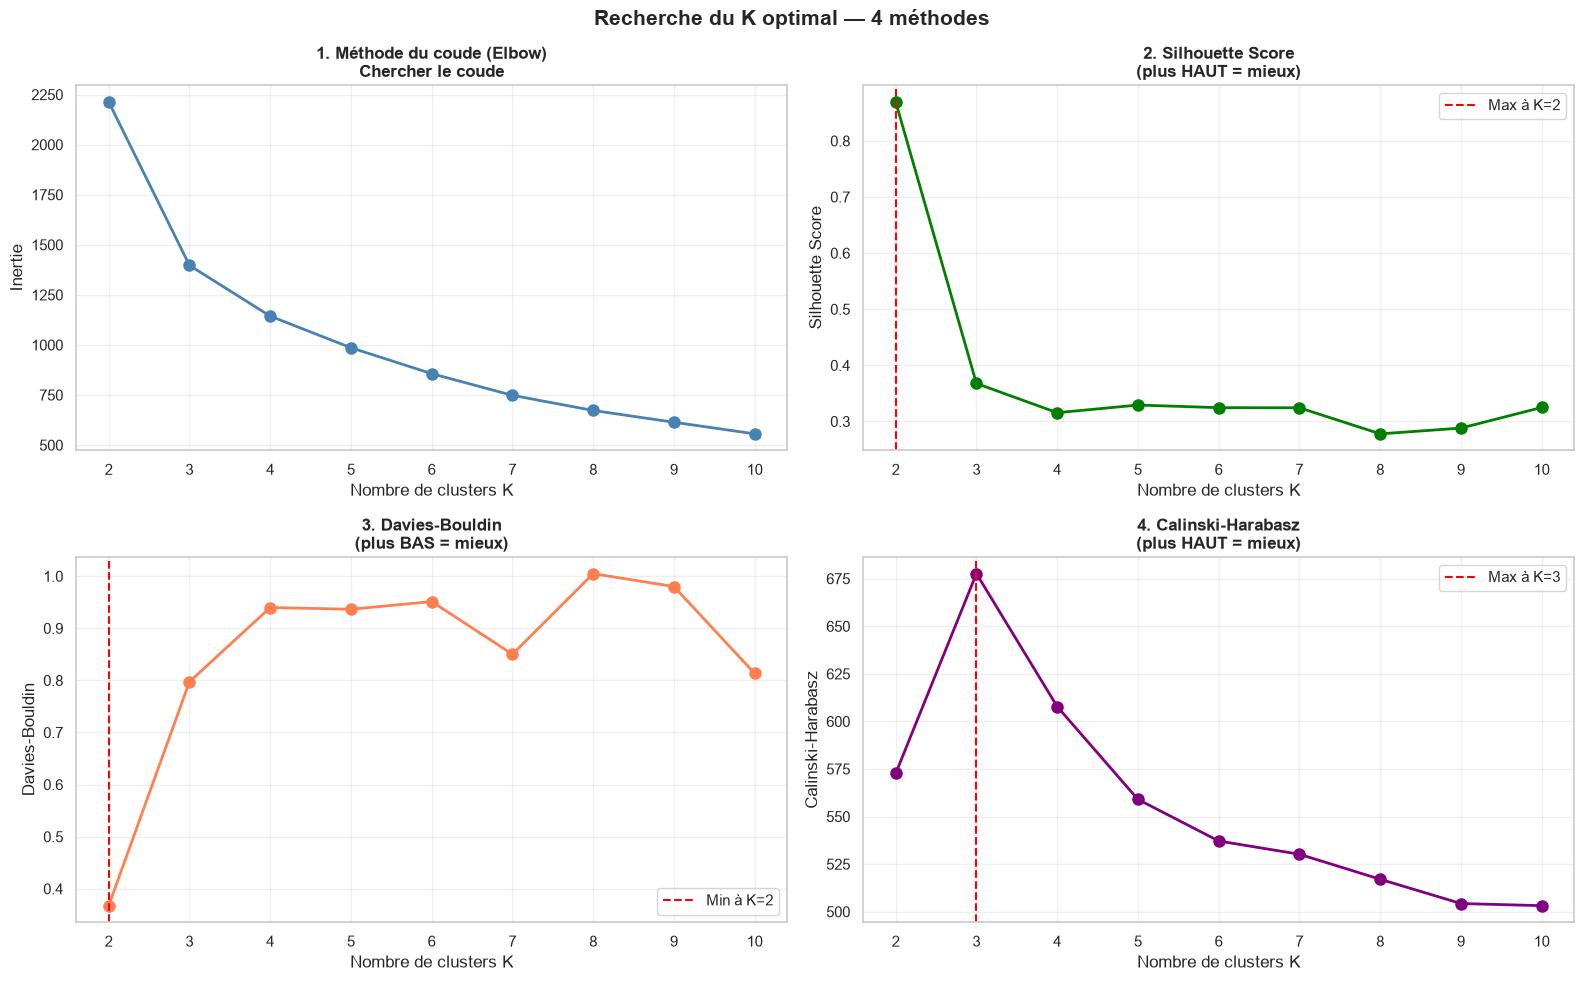

RECOMMANDATIONS :
  Silhouette        recommande K = 2
  Davies-Bouldin    recommande K = 2
  Calinski-Harabasz recommande K = 3

=> K optimal retenu : 2 (basé sur Silhouette)


In [15]:
# ============================================================
# VISUALISATION DES 3 MÉTHODES
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Elbow (inertie)
axes[0,0].plot(list(K_range), inerties, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0,0].set_xlabel('Nombre de clusters K')
axes[0,0].set_ylabel('Inertie')
axes[0,0].set_title('1. Méthode du coude (Elbow)\nChercher le coude', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# 2. Silhouette (max = mieux)
best_sil_k = list(K_range)[np.argmax(silhouettes)]
axes[0,1].plot(list(K_range), silhouettes, 'o-', color='green', linewidth=2, markersize=8)
axes[0,1].axvline(best_sil_k, color='red', linestyle='--', label=f'Max à K={best_sil_k}')
axes[0,1].set_xlabel('Nombre de clusters K')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].set_title('2. Silhouette Score\n(plus HAUT = mieux)', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Davies-Bouldin (min = mieux)
best_db_k = list(K_range)[np.argmin(davies)]
axes[1,0].plot(list(K_range), davies, 'o-', color='coral', linewidth=2, markersize=8)
axes[1,0].axvline(best_db_k, color='red', linestyle='--', label=f'Min à K={best_db_k}')
axes[1,0].set_xlabel('Nombre de clusters K')
axes[1,0].set_ylabel('Davies-Bouldin')
axes[1,0].set_title('3. Davies-Bouldin\n(plus BAS = mieux)', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Calinski-Harabasz (max = mieux)
best_ch_k = list(K_range)[np.argmax(calinski)]
axes[1,1].plot(list(K_range), calinski, 'o-', color='purple', linewidth=2, markersize=8)
axes[1,1].axvline(best_ch_k, color='red', linestyle='--', label=f'Max à K={best_ch_k}')
axes[1,1].set_xlabel('Nombre de clusters K')
axes[1,1].set_ylabel('Calinski-Harabasz')
axes[1,1].set_title('4. Calinski-Harabasz\n(plus HAUT = mieux)', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Recherche du K optimal — 4 méthodes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'RECOMMANDATIONS :')
print(f'  Silhouette        recommande K = {best_sil_k}')
print(f'  Davies-Bouldin    recommande K = {best_db_k}')
print(f'  Calinski-Harabasz recommande K = {best_ch_k}')

# K optimal = celui recommandé par la silhouette (le plus fiable en général)
K_OPTIMAL = best_sil_k
print(f'\n=> K optimal retenu : {K_OPTIMAL} (basé sur Silhouette)')

---
## 4. Comparaison de 3 algorithmes de clustering

### Pourquoi comparer plusieurs algorithmes ?
K-Means n'est pas toujours le meilleur. On teste 3 approches différentes :

| Algorithme | Principe | Force |
|---|---|---|
| **K-Means** | Centres de clusters | Rapide, simple |
| **Hiérarchique** | Fusionne progressivement | Pas besoin de fixer K a priori |
| **DBSCAN** | Densité des points | Détecte les formes complexes + outliers |

In [16]:
# ============================================================
# ENTRAÎNER LES 3 ALGORITHMES
# ============================================================

def evaluer_clustering(X, labels, nom):
    """Calcule les 3 métriques de qualité d'un clustering."""
    # DBSCAN peut mettre des points en -1 (bruit) — on gère le cas
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return {'Algorithme': nom, 'N_clusters': n_clusters,
                'Silhouette': np.nan, 'Davies_Bouldin': np.nan,
                'Calinski': np.nan}
    # Pour les métriques, on exclut le bruit DBSCAN
    mask = labels != -1
    return {
        'Algorithme'    : nom,
        'N_clusters'    : n_clusters,
        'Silhouette'    : silhouette_score(X[mask], labels[mask]),
        'Davies_Bouldin': davies_bouldin_score(X[mask], labels[mask]),
        'Calinski'      : calinski_harabasz_score(X[mask], labels[mask])
    }

resultats_algos = []

# 1. K-Means
km = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)
resultats_algos.append(evaluer_clustering(X_scaled, labels_km, 'K-Means'))

# 2. Clustering hiérarchique
hier = AgglomerativeClustering(n_clusters=K_OPTIMAL)
labels_hier = hier.fit_predict(X_scaled)
resultats_algos.append(evaluer_clustering(X_scaled, labels_hier, 'Hiérarchique'))

# 3. DBSCAN (basé densité — pas besoin de K)
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
resultats_algos.append(evaluer_clustering(X_scaled, labels_db, 'DBSCAN'))

df_algos = pd.DataFrame(resultats_algos)
print('=' * 60)
print('COMPARAISON DES 3 ALGORITHMES')
print('=' * 60)
display(df_algos.round(3))

print('\nRappel interprétation :')
print('  Silhouette     : plus HAUT = mieux')
print('  Davies_Bouldin : plus BAS = mieux')
print('  Calinski       : plus HAUT = mieux')

COMPARAISON DES 3 ALGORITHMES


,Algorithme,N_clusters,Silhouette,Davies_Bouldin,Calinski
0,K-Means,2,0.87,0.368,572.622
1,Hiérarchique,2,0.87,0.368,572.622
2,DBSCAN,1,NaN,NaN,NaN



Rappel interprétation :
  Silhouette     : plus HAUT = mieux
  Davies_Bouldin : plus BAS = mieux
  Calinski       : plus HAUT = mieux


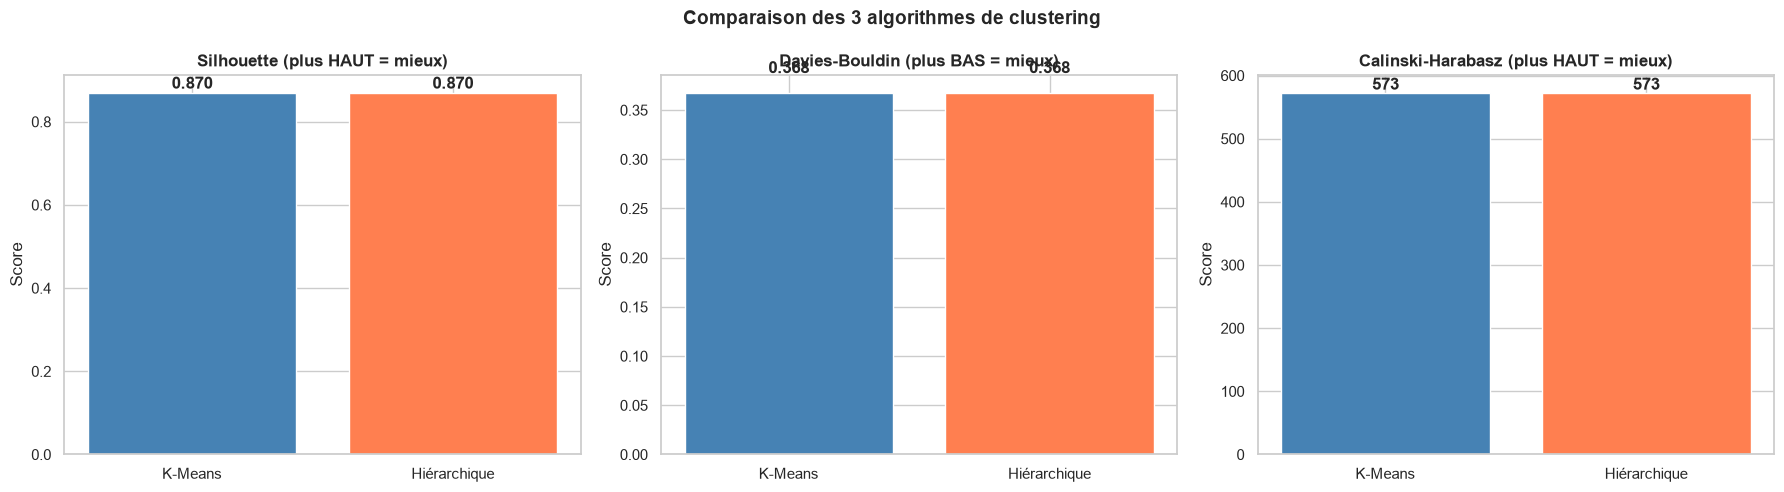


Meilleur algorithme (Silhouette max) : K-Means


In [17]:
# ============================================================
# GRAPHIQUE COMPARATIF DES ALGORITHMES
# ============================================================
df_valid = df_algos.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(df_valid['Algorithme'], df_valid['Silhouette'],
            color=['steelblue','coral','green'], edgecolor='white')
axes[0].set_title('Silhouette (plus HAUT = mieux)', fontweight='bold')
axes[0].set_ylabel('Score')
for i, v in enumerate(df_valid['Silhouette']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(df_valid['Algorithme'], df_valid['Davies_Bouldin'],
            color=['steelblue','coral','green'], edgecolor='white')
axes[1].set_title('Davies-Bouldin (plus BAS = mieux)', fontweight='bold')
axes[1].set_ylabel('Score')
for i, v in enumerate(df_valid['Davies_Bouldin']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(df_valid['Algorithme'], df_valid['Calinski'],
            color=['steelblue','coral','green'], edgecolor='white')
axes[2].set_title('Calinski-Harabasz (plus HAUT = mieux)', fontweight='bold')
axes[2].set_ylabel('Score')
for i, v in enumerate(df_valid['Calinski']):
    axes[2].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

plt.suptitle('Comparaison des 3 algorithmes de clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Meilleur algorithme = silhouette max
best_algo = df_valid.loc[df_valid['Silhouette'].idxmax(), 'Algorithme']
print(f'\nMeilleur algorithme (Silhouette max) : {best_algo}')

---
## 5. Dendrogramme (Clustering Hiérarchique)

### Pourquoi ?
Le dendrogramme montre visuellement comment les arrêts se regroupent
progressivement. La hauteur des branches indique la distance entre groupes.
On peut 'couper' le dendrogramme à différentes hauteurs pour obtenir K clusters.

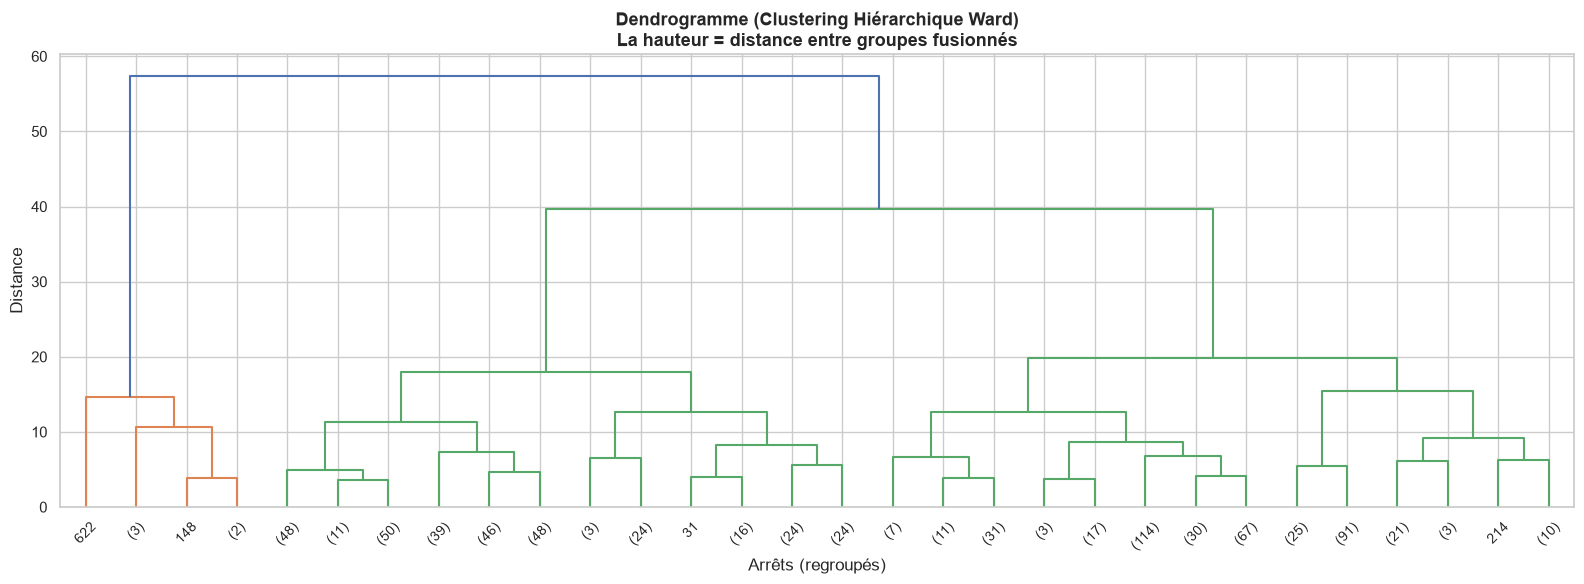

In [8]:
# Dendrogramme sur un échantillon (sinon illisible avec 772 arrêts)
linked = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linked, truncate_mode='lastp', p=30, ax=ax,
           show_leaf_counts=True)
ax.set_title('Dendrogramme (Clustering Hiérarchique Ward)\n'
             'La hauteur = distance entre groupes fusionnés',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Arrêts (regroupés)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

---
## 6. Visualisation PCA en 2D

### Pourquoi le PCA ?
Nos arrêts sont décrits par 5 features — impossible à visualiser en 5 dimensions.
Le PCA (Analyse en Composantes Principales) **réduit** ces 5 dimensions à 2,
tout en gardant le maximum d'information. On peut alors dessiner les clusters
sur un graphique 2D.

**Le PCA n'est PAS un algorithme de clustering** — c'est un outil de
**réduction de dimensions** pour visualiser.

In [18]:
# ============================================================
# PCA — Réduction à 2 dimensions
# ============================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée : combien d'information on garde avec 2 dimensions ?
var_expliquee = pca.explained_variance_ratio_
print(f'Variance expliquée par les 2 composantes PCA :')
print(f'  Composante 1 : {var_expliquee[0]*100:.1f}%')
print(f'  Composante 2 : {var_expliquee[1]*100:.1f}%')
print(f'  TOTAL        : {var_expliquee.sum()*100:.1f}% de l information conservée')

# Ajouter les labels K-Means au dataframe des profils
df_profils['cluster'] = labels_km
df_profils['pca1'] = X_pca[:, 0]
df_profils['pca2'] = X_pca[:, 1]

# Visualisation interactive
fig = px.scatter(
    df_profils, x='pca1', y='pca2',
    color='cluster',
    hover_name='LIBELLE_ARRET',
    hover_data=['volume_total', 'ratio_we_semaine'],
    title=f'Clusters des arrêts visualisés en PCA 2D (K={K_OPTIMAL})',
    labels={'pca1': f'PCA 1 ({var_expliquee[0]*100:.0f}%)',
            'pca2': f'PCA 2 ({var_expliquee[1]*100:.0f}%)'},
    color_continuous_scale='Viridis'
)
fig.update_traces(marker=dict(size=8))
fig.update_layout(height=600)
fig.show()

Variance expliquée par les 2 composantes PCA :
  Composante 1 : 64.6%
  Composante 2 : 26.0%
  TOTAL        : 90.6% de l information conservée


---
## 7. Interprétation métier des clusters

### Pourquoi ?
Les numéros de clusters (0, 1, 2...) ne veulent rien dire.
On analyse les caractéristiques de chaque cluster pour leur donner
un **nom métier** (Hub, Résidentiel, Touristique...).

In [19]:
# Forcer K=5 pour voir les profils métier
K_OPTIMAL = 5
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)
df_profils['cluster'] = labels_km
print("Clustering refait avec K=5")

Clustering refait avec K=5


Caractéristiques moyennes par cluster :


,trafic_moyen_semaine,trafic_moyen_weekend,ratio_we_semaine,volume_total,coef_variation,nb_arrets
cluster,,,,,,
0,16289.2,12674.8,0.8,1389286.3,0.3,106
1,3240.7,1485.2,0.4,245224.9,0.5,284
2,129849.2,94460.0,0.7,11026007.1,0.2,7
3,2946.6,1363.0,0.5,214874.1,0.7,41
4,6465.1,4155.4,0.7,521388.1,0.3,334


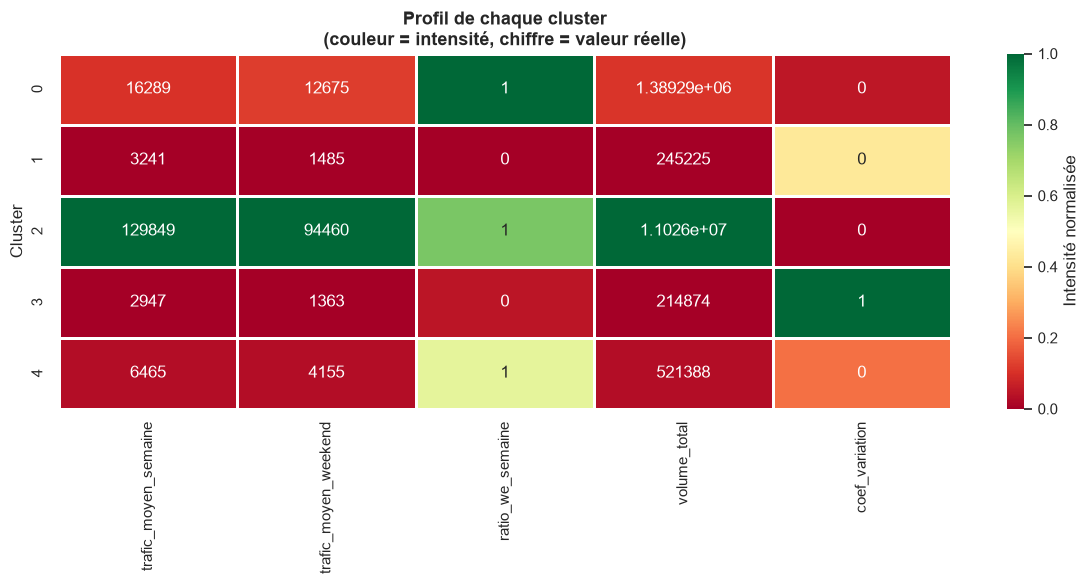

In [20]:
# ============================================================
# CARACTÉRISTIQUES MOYENNES DE CHAQUE CLUSTER
# ============================================================
profil_clusters = df_profils.groupby('cluster')[FEATURES_CLUSTER].mean()
profil_clusters['nb_arrets'] = df_profils.groupby('cluster').size()

print('Caractéristiques moyennes par cluster :')
display(profil_clusters.round(1))

# Heatmap des profils
from sklearn.preprocessing import MinMaxScaler
profil_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(profil_clusters[FEATURES_CLUSTER]),
    columns=FEATURES_CLUSTER,
    index=profil_clusters.index
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(profil_norm, annot=profil_clusters[FEATURES_CLUSTER].round(0),
            fmt='g', cmap='RdYlGn', linewidths=1, ax=ax,
            cbar_kws={'label': 'Intensité normalisée'})
ax.set_title('Profil de chaque cluster\n(couleur = intensité, chiffre = valeur réelle)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# EXEMPLES D'ARRÊTS PAR CLUSTER
# ============================================================
# On regarde quels arrêts connus sont dans chaque cluster
# pour valider l'interprétation métier

for c in sorted(df_profils['cluster'].unique()):
    arrets_cluster = df_profils[df_profils['cluster'] == c]
    top_arrets = arrets_cluster.nlargest(8, 'volume_total')['LIBELLE_ARRET'].tolist()
    print(f'\nCLUSTER {c} — {len(arrets_cluster)} arrêts')
    print(f'  Trafic semaine moyen : {arrets_cluster["trafic_moyen_semaine"].mean():,.0f}')
    print(f'  Ratio week-end/semaine : {arrets_cluster["ratio_we_semaine"].mean():.2f}')
    print(f'  Exemples : {", ".join(top_arrets[:6])}')


CLUSTER 0 — 765 arrêts
  Trafic semaine moyen : 6,441
  Ratio week-end/semaine : 0.59
  Exemples : CH.D.G.ETOILE, LES HALLES, REPUBLIQUE, NATION, BASTILLE, HOTEL DE VILLE

CLUSTER 1 — 7 arrêts
  Trafic semaine moyen : 129,849
  Ratio week-end/semaine : 0.73
  Exemples : SAINT-LAZARE, CHATELET, GARE DE LYON, MONTPARNASSE, LA DEFENSE, GARE DU NORD


---
## 8. Résumé

La sauvegarde officielle du modèle se fera dans `src/train_clustering.py`
(principe de séparation des responsabilités).

In [12]:
print('=' * 55)
print('RÉSUMÉ MODÈLE 3 — Clustering des arrêts')
print('=' * 55)
print(f'''
RECHERCHE DU K OPTIMAL
  Silhouette        recommande K = {best_sil_k}
  Davies-Bouldin    recommande K = {best_db_k}
  Calinski-Harabasz recommande K = {best_ch_k}
  => K retenu : {K_OPTIMAL}

COMPARAISON DES ALGORITHMES
  Meilleur : {best_algo} (silhouette la plus élevée)

VISUALISATION
  PCA 2D conserve {var_expliquee.sum()*100:.0f}% de l information

PROCHAINE ÉTAPE
  Sauvegarde via src/train_clustering.py
  Puis explicabilité SHAP sur le modèle de trafic
''')

RÉSUMÉ MODÈLE 3 — Clustering des arrêts

RECHERCHE DU K OPTIMAL
  Silhouette        recommande K = 2
  Davies-Bouldin    recommande K = 2
  Calinski-Harabasz recommande K = 3
  => K retenu : 2

COMPARAISON DES ALGORITHMES
  Meilleur : K-Means (silhouette la plus élevée)

VISUALISATION
  PCA 2D conserve 91% de l information

PROCHAINE ÉTAPE
  Sauvegarde via src/train_clustering.py
  Puis explicabilité SHAP sur le modèle de trafic

